# Chunk Size + Retrieval Configuration Experiment (Full Corpus)

This notebook tests whether the following parameters influence model performance: chunk size, number of retrieved documents and embedding strategy

In [1]:
# Import the required packages
import sys
import pysqlite3
sys.modules["sqlite3"] = sys.modules["pysqlite3"]

import json
import re
from pathlib import Path

# Load the exchange corpus
with open("unified_text_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)
print(f"Loaded {len(corpus)} source documents.")

Loaded 9603 source documents.


In [2]:
# Import the required packages
from transformers import AutoTokenizer

# Load the BGE-M3 tokenizer
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

# Set the over lap ratio
OVERLAP_RATIO = 0.2 

# Define the count tokens function
def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

# Define the sentence split function
def split_into_sentences(text: str) -> list:
    text = text.replace("\n", " ")
    sentences = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9])", text)
    return [s.strip() for s in sentences if s.strip()]

# Define the recursive character split function
def recursive_char_split(text: str, max_tokens: int) -> list:
    if count_tokens(text) <= max_tokens:
        return [text]
    for sep in ["\n\n", "\n", ". ", " "]:
        if sep in text:
            parts = text.split(sep)
            chunks, current = [], ""
            for part in parts:
                candidate = (current + sep + part) if current else part
                if count_tokens(candidate) <= max_tokens:
                    current = candidate
                else:
                    if current:
                        chunks.append(current)
                    current = part
            if current:
                chunks.append(current)
            final = []
            for c in chunks:
                final.extend(recursive_char_split(c, max_tokens) if count_tokens(c) > max_tokens else [c])
            return final
    approx_chars_per_token = 4
    cut = max_tokens * approx_chars_per_token
    return [text[i:i+cut] for i in range(0, len(text), cut)]

# Define the chunking function
def chunk_document(text: str, chunk_size: int, overlap: int) -> list:
    sentences = split_into_sentences(text)
    if not sentences:
        return []
    chunks, current_sentences, current_tokens = [], [], 0
    for sentence in sentences:
        sentence_tokens = count_tokens(sentence)
        if sentence_tokens > chunk_size:
            if current_sentences:
                chunks.append(" ".join(current_sentences))
                current_sentences, current_tokens = [], 0
            chunks.extend(recursive_char_split(sentence, chunk_size))
            continue
        if current_tokens + sentence_tokens > chunk_size:
            chunks.append(" ".join(current_sentences))
            overlap_sentences, overlap_tokens = [], 0
            for s in reversed(current_sentences):
                t = count_tokens(s)
                if overlap_tokens + t > overlap:
                    break
                overlap_sentences.insert(0, s)
                overlap_tokens += t
            current_sentences = overlap_sentences + [sentence]
            current_tokens = overlap_tokens + sentence_tokens
        else:
            current_sentences.append(sentence)
            current_tokens += sentence_tokens
    if current_sentences:
        chunks.append(" ".join(current_sentences))
    return chunks

In [3]:
# Set the evaluating chunk sizes
CHUNK_SIZES = [256, 512, 1024]

# Chunk the corpus in the above chunk sizes for testing
for chunk_size in CHUNK_SIZES:
    out_path = Path(f"corpus_chunks_{chunk_size}.json")
    if out_path.exists():
        print(f"chunk_size={chunk_size}: {out_path} already exists, skipping re-chunk.")
        continue

    overlap = int(chunk_size * OVERLAP_RATIO)
    chunks_for_size = []
    for doc in corpus:
        doc_chunks = chunk_document(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for i, chunk_text in enumerate(doc_chunks):
            chunks_for_size.append({
                "chunk_id": f"{doc['id']}-cs{chunk_size}-chunk{i}", "doc_id": doc["id"],
                "exchange": doc["exchange"], "doc_type": doc["doc_type"], "title": doc["title"],
                "date": doc["date"], "company": doc["company"], "url": doc["url"],
                "retrieved_via": doc["retrieved_via"], "chunk_index": i, "text": chunk_text,
                "token_count": count_tokens(chunk_text),
            })

    out_path.write_text(json.dumps(chunks_for_size, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"chunk_size={chunk_size}: created {len(chunks_for_size)} chunks -> {out_path}")

Token indices sequence length is longer than the specified maximum sequence length for this model (8560 > 8192). Running this sequence through the model will result in indexing errors


chunk_size=256: created 180807 chunks -> corpus_chunks_256.json
chunk_size=512: created 93334 chunks -> corpus_chunks_512.json
chunk_size=1024: created 49837 chunks -> corpus_chunks_1024.json


In [4]:
# Import the required packages
import numpy as np
from FlagEmbedding import BGEM3FlagModel

# Load the BGE-M3 embedding model
if "embed_model" not in dir():
    print("Loading BGE-M3 embedding model...")
    embed_model = BGEM3FlagModel("BAAI/bge-m3", use_fp16=True)
    print("Model loaded.")

# Set the bathc sizes
EMBEDDING_BATCH_SIZE = 16
SEP = "=" * 60

# Embed the chunks for each chunk size
for TARGET_CHUNK_SIZE in CHUNK_SIZES:
    print(SEP)
    print("Processing chunk_size=" + str(TARGET_CHUNK_SIZE))
    print(SEP)

    chunks_path = Path(f"corpus_chunks_{TARGET_CHUNK_SIZE}.json")
    if not chunks_path.exists():
        print(f"  chunk_size={TARGET_CHUNK_SIZE}: corpus_chunks_{TARGET_CHUNK_SIZE}.json not found -- run cell 1.4 first.")
        continue

    with open(chunks_path, "r", encoding="utf-8") as f:
        chunks_for_size = json.load(f)
    print(f"  {len(chunks_for_size)} chunks to embed.")

    embeddings_path    = Path(f"chunk_embeddings_{TARGET_CHUNK_SIZE}.npy")
    sparse_weights_path = Path(f"chunk_sparse_weights_{TARGET_CHUNK_SIZE}.json")
    progress_path      = Path(f"embedding_progress_{TARGET_CHUNK_SIZE}.json")

    # Resume from checkpoint if one exists for this size
    if embeddings_path.exists() and sparse_weights_path.exists() and progress_path.exists():
        all_embeddings_this_size = np.load(embeddings_path)
        with open(sparse_weights_path, "r") as f:
            all_sparse_weights_this_size = json.load(f)
        with open(progress_path, "r") as f:
            processed_count = json.load(f)["processed_count"]
        if processed_count >= len(chunks_for_size):
            print(f"  chunk_size={TARGET_CHUNK_SIZE}: already fully embedded ({processed_count}/{len(chunks_for_size)} chunks). Skipping.")
            continue
        print(f"  Resuming chunk_size={TARGET_CHUNK_SIZE} -- {processed_count}/{len(chunks_for_size)} already embedded.")
    else:
        probe_output = embed_model.encode(
            [chunks_for_size[0]["text"]], return_dense=True,
            return_sparse=True, return_colbert_vecs=False,
        )
        dim = probe_output["dense_vecs"].shape[1]
        all_embeddings_this_size = np.zeros((0, dim), dtype=np.float32)
        all_sparse_weights_this_size = {}
        processed_count = 0
        print(f"  Starting fresh embedding for chunk_size={TARGET_CHUNK_SIZE}.")

    remaining = chunks_for_size[processed_count:]
    print(f"  Embedding {len(remaining)} remaining chunks...")

    max_length = TARGET_CHUNK_SIZE + int(TARGET_CHUNK_SIZE * OVERLAP_RATIO)

    for batch_start in range(0, len(remaining), EMBEDDING_BATCH_SIZE):
        batch = remaining[batch_start:batch_start + EMBEDDING_BATCH_SIZE]
        batch_texts = [c["text"] for c in batch]

        output = embed_model.encode(
            batch_texts,
            batch_size=EMBEDDING_BATCH_SIZE,
            max_length=max_length,
            return_dense=True,
            return_sparse=True,
            return_colbert_vecs=False,
        )
        all_embeddings_this_size = np.vstack([all_embeddings_this_size, output["dense_vecs"]])
        for chunk, sparse_w in zip(batch, output["lexical_weights"]):
            all_sparse_weights_this_size[chunk["chunk_id"]] = {
                str(k): float(v) for k, v in sparse_w.items()
            }

        processed_count += len(batch)

        # Checkpoint every 10 batches
        if (batch_start // EMBEDDING_BATCH_SIZE) % 10 == 0:
            np.save(embeddings_path, all_embeddings_this_size)
            with open(sparse_weights_path, "w") as f:
                json.dump(all_sparse_weights_this_size, f)
            with open(progress_path, "w") as f:
                json.dump({"processed_count": processed_count}, f)
            total = len(chunks_for_size)
            pct = processed_count / total * 100
            print(f"  Checkpoint: {processed_count}/{total} ({pct:.1f}%)")

    # Final save for this size
    np.save(embeddings_path, all_embeddings_this_size)
    with open(sparse_weights_path, "w") as f:
        json.dump(all_sparse_weights_this_size, f)
    with open(progress_path, "w") as f:
        json.dump({"processed_count": processed_count}, f)

    shape = all_embeddings_this_size.shape
    n_sparse = len(all_sparse_weights_this_size)
    print(f"  Done. chunk_size={TARGET_CHUNK_SIZE}: shape={shape}, sparse weights={n_sparse} chunks.")

Loading BGE-M3 embedding model...


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

/home/areas001/.local/lib/python3.8/site-packages/FlagEmbedding/BGE_M3/modeling.py:335: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  colbert_state_dict = torch.load(os.path

Model loaded.
Processing chunk_size=256
  180807 chunks to embed.
  Starting fresh embedding for chunk_size=256.
  Embedding 180807 remaining chunks...
  Checkpoint: 16/180807 (0.0%)
  Checkpoint: 176/180807 (0.1%)
  Checkpoint: 336/180807 (0.2%)
  Checkpoint: 496/180807 (0.3%)
  Checkpoint: 656/180807 (0.4%)
  Checkpoint: 816/180807 (0.5%)
  Checkpoint: 976/180807 (0.5%)
  Checkpoint: 1136/180807 (0.6%)
  Checkpoint: 1296/180807 (0.7%)
  Checkpoint: 1456/180807 (0.8%)
  Checkpoint: 1616/180807 (0.9%)
  Checkpoint: 1776/180807 (1.0%)
  Checkpoint: 1936/180807 (1.1%)
  Checkpoint: 2096/180807 (1.2%)
  Checkpoint: 2256/180807 (1.2%)
  Checkpoint: 2416/180807 (1.3%)
  Checkpoint: 2576/180807 (1.4%)
  Checkpoint: 2736/180807 (1.5%)
  Checkpoint: 2896/180807 (1.6%)
  Checkpoint: 3056/180807 (1.7%)
  Checkpoint: 3216/180807 (1.8%)
  Checkpoint: 3376/180807 (1.9%)
  Checkpoint: 3536/180807 (2.0%)
  Checkpoint: 3696/180807 (2.0%)
  Checkpoint: 3856/180807 (2.1%)
  Checkpoint: 4016/180807 (2.2%

In [5]:
# Import the required packages
import chromadb

# Load in the knowledge base chunks
chroma_client = chromadb.PersistentClient(path="./chroma_knowledge_base_chunk_experiments")

# Define a function to build the knowledge base for each chunk size
def build_collection_for_size(chunk_size: int):
    with open(f"corpus_chunks_{chunk_size}.json", "r", encoding="utf-8") as f:
        chunks_for_size = json.load(f)
    embeddings = np.load(f"chunk_embeddings_{chunk_size}.npy")

    collection = chroma_client.get_or_create_collection(
        name=f"kb_chunksize_{chunk_size}", metadata={"hnsw:space": "cosine"},
    )
    if collection.count() >= len(chunks_for_size):
        print(f"chunk_size={chunk_size}: collection already has {collection.count()} chunks, skipping.")
        return

    BATCH_SIZE = 100
    for i in range(0, len(chunks_for_size), BATCH_SIZE):
        batch_chunks = chunks_for_size[i:i + BATCH_SIZE]
        batch_embeddings = embeddings[i:i + BATCH_SIZE]
        collection.add(
            ids=[c["chunk_id"] for c in batch_chunks],
            embeddings=batch_embeddings.tolist(),
            documents=[c["text"] for c in batch_chunks],
            metadatas=[{
                "exchange": c["exchange"], "doc_type": c["doc_type"], "title": c["title"] or "",
                "date": str(c["date"]) if c["date"] else "", "company": c["company"] or "",
                "url": c["url"] or "", "retrieved_via": c["retrieved_via"],
            } for c in batch_chunks],
        )
    print(f"chunk_size={chunk_size}: collection built with {collection.count()} chunks.")


# Run for whichever sizes have finished embedding so far
for size in CHUNK_SIZES:
    if Path(f"chunk_embeddings_{size}.npy").exists():
        build_collection_for_size(size)
    else:
        print(f"chunk_size={size}: no embeddings file yet -- run 1.5 for this size first.")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
chunk_size=256: collection already has 180807 chunks, skipping.
chunk_size=512: collection already has 93334 chunks, skipping.
chunk_size=1024: collection already has 49837 chunks, skipping.


In [6]:
# Load in the QA evaluation set
with open("qa_draft_set.json", "r", encoding="utf-8") as f:
    qa_set = json.load(f)
qa_set = [q for q in qa_set if q.get("human_verified", False)]
evaluable_questions = [q for q in qa_set if q.get("source_url")]
print(f"{len(evaluable_questions)} verified questions with a known source URL.")

# Load the weights for each chunk size
sparse_weights_by_size = {}
for size in CHUNK_SIZES:
    path = Path(f"chunk_sparse_weights_{size}.json")
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            sparse_weights_by_size[size] = json.load(f)
        print(f"chunk_size={size}: loaded {len(sparse_weights_by_size[size])} sparse weight entries.")

102 verified questions with a known source URL.
chunk_size=256: loaded 180807 sparse weight entries.
chunk_size=512: loaded 93334 sparse weight entries.
chunk_size=1024: loaded 49837 sparse weight entries.


In [7]:
def min_max_normalize(scores):
    if not scores:
        return []
    lo, hi = min(scores), max(scores)
    if hi == lo:
        return [1.0 for _ in scores]
    return [(s - lo) / (hi - lo) for s in scores]

# Define the hybrid search function combining semantic similarity and sparse lexical matching
def hybrid_search_for_size(query, chunk_size, alpha, top_k, candidate_k=30):
    collection = chroma_client.get_collection(name=f"kb_chunksize_{chunk_size}")
    sparse_weights = sparse_weights_by_size[chunk_size]

    query_output = embed_model.encode([query], return_dense=True, return_sparse=True, return_colbert_vecs=False)
    query_dense = query_output["dense_vecs"][0].tolist()
    query_sparse = query_output["lexical_weights"][0]

    chroma_results = collection.query(query_embeddings=[query_dense], n_results=candidate_k)
    candidate_ids = chroma_results["ids"][0]
    candidate_metas = chroma_results["metadatas"][0]
    candidate_distances = chroma_results["distances"][0]

    dense_scores = [1 - d for d in candidate_distances]
    sparse_scores = [
        float(embed_model.compute_lexical_matching_score(query_sparse, sparse_weights.get(cid, {})))
        for cid in candidate_ids
    ]
    dense_norm = min_max_normalize(dense_scores)
    sparse_norm = min_max_normalize(sparse_scores)
    hybrid_scores = [alpha * d + (1 - alpha) * s for d, s in zip(dense_norm, sparse_norm)]

    ranked = sorted(zip(candidate_ids, candidate_metas, hybrid_scores), key=lambda x: x[-1], reverse=True)
    return [{"chunk_id": cid, "metadata": meta} for cid, meta, _ in ranked[:top_k]]

# Define the function to calculate the retrieval hit-rate
def check_hit(question_record, retrieved):
    target_url = question_record.get("source_url", "")
    if not target_url:
        return None
    return any(r["metadata"].get("url") == target_url for r in retrieved)

## 2.3 Run the full sweep

In [8]:
# Import the required packages
import pandas as pd

# Set the alpha and Top K test values
ALPHA_VALUES = [0.0, 0.3, 0.5, 0.7, 1.0]
TOP_K_VALUES = [3, 5, 10]

# Calculate the hit rate for the different config combinations
sweep_results = []
for chunk_size in CHUNK_SIZES:
    if chunk_size not in sparse_weights_by_size:
        print(f"chunk_size={chunk_size}: not ready yet, skipping.")
        continue

    for alpha in ALPHA_VALUES:
        for top_k in TOP_K_VALUES:
            hits = 0
            for q in evaluable_questions:
                retrieved = hybrid_search_for_size(q["question"], chunk_size, alpha, top_k)
                if check_hit(q, retrieved):
                    hits += 1
            hit_rate = hits / len(evaluable_questions) if evaluable_questions else 0
            sweep_results.append({"chunk_size": chunk_size, "alpha": alpha, "top_k": top_k, "hit_rate": hit_rate})
            print(f"chunk_size = {chunk_size}, alpha = {alpha}, top_k = {top_k}: hit_rate = {hit_rate:.3f}")

# Save the results in a DataFrame and in csv
full_sweep_df = pd.DataFrame(sweep_results)
full_sweep_df.to_csv("full_chunk_size_retrieval_sweep.csv", index = False)

chunk_size = 256, alpha = 0.0, top_k = 3: hit_rate = 0.471
chunk_size = 256, alpha = 0.0, top_k = 5: hit_rate = 0.510
chunk_size = 256, alpha = 0.0, top_k = 10: hit_rate = 0.529
chunk_size = 256, alpha = 0.3, top_k = 3: hit_rate = 0.461
chunk_size = 256, alpha = 0.3, top_k = 5: hit_rate = 0.500
chunk_size = 256, alpha = 0.3, top_k = 10: hit_rate = 0.549
chunk_size = 256, alpha = 0.5, top_k = 3: hit_rate = 0.480
chunk_size = 256, alpha = 0.5, top_k = 5: hit_rate = 0.490
chunk_size = 256, alpha = 0.5, top_k = 10: hit_rate = 0.549
chunk_size = 256, alpha = 0.7, top_k = 3: hit_rate = 0.461
chunk_size = 256, alpha = 0.7, top_k = 5: hit_rate = 0.490
chunk_size = 256, alpha = 0.7, top_k = 10: hit_rate = 0.520
chunk_size = 256, alpha = 1.0, top_k = 3: hit_rate = 0.441
chunk_size = 256, alpha = 1.0, top_k = 5: hit_rate = 0.480
chunk_size = 256, alpha = 1.0, top_k = 10: hit_rate = 0.520
chunk_size = 512, alpha = 0.0, top_k = 3: hit_rate = 0.431
chunk_size = 512, alpha = 0.0, top_k = 5: hit_rate 

In [9]:
# Identify and show the top 3 configurations
top_configs = full_sweep_df.sort_values("hit_rate", ascending = False).head(3)
print("Top 3 configurations by retrieval hit rate:")
print(top_configs)

Top 3 configurations by retrieval hit rate:
    chunk_size  alpha  top_k  hit_rate
8          256    0.5     10  0.549020
5          256    0.3     10  0.549020
35        1024    0.3     10  0.539216


In [10]:
# Import required packages
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

# Set the hugging face token
HF_TOKEN = ""

# Specifies the Llama build and 4-bit quantization
GGUF_REPO = "bartowski/Meta-Llama-3.1-8B-Instruct-GGUF"
GGUF_FILENAME = "Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf"

# Downloads the model file
model_path = hf_hub_download(repo_id = GGUF_REPO, filename = GGUF_FILENAME, token = HF_TOKEN)

# Load in the Llama 3.1B Instruct model
llm = Llama(
    model_path = model_path,
    n_ctx = 8192,
    n_threads = 8,
    verbose = False,)

In [18]:
# Define baseline model prompts
BASELINE_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question as accurately as you can.")

# Define RAG model prompts
RAG_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question using ONLY the context provided below. If the context does not contain enough "
    "information to answer, say so explicitly rather than guessing.")

# Set the maximum number of tokens
MAX_CONTEXT_TOKENS = 6000

# Define function to trim retrieved chunk so they fit into the token limit
def build_context_within_limit(retrieved_chunks: list, max_tokens: int = MAX_CONTEXT_TOKENS) -> list:
    included = []
    running_tokens = 0
    for chunk_text in retrieved_chunks:
        chunk_tokens = count_tokens(chunk_text)  # no ["text"] indexing -- chunk_text IS the text
        if running_tokens + chunk_tokens > max_tokens:
            break
        included.append(chunk_text)
        running_tokens += chunk_tokens
    return included

# Define baseline model prompts
BASELINE_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question as accurately as you can.")

# Define RAG model prompts
RAG_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question using ONLY the context provided below. If the context does not contain enough "
    "information to answer, say so explicitly rather than guessing.")

# Define baseline answer generation function
def generate_baseline_answer(question: str, max_tokens: int = 300) -> str:
    messages = [
        {"role": "system", "content": BASELINE_SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    response = llm.create_chat_completion(messages=messages, max_tokens = max_tokens, temperature = 0.3)
    return response["choices"][0]["message"]["content"].strip()


# Define RAG answer generation function
def generate_rag_answer(question, retrieved_chunks_text, max_tokens=300):
    budgeted_chunks = build_context_within_limit(retrieved_chunks_text)
    if len(budgeted_chunks) < len(retrieved_chunks_text):
        print(f"    (context budget: using {len(budgeted_chunks)}/{len(retrieved_chunks_text)} "
             f"retrieved chunks to stay within {MAX_CONTEXT_TOKENS} tokens)")

    context_text = "\n\n".join(f"[Source {i+1}] {t}" for i, t in enumerate(budgeted_chunks))
    user_message = f"Context:\n{context_text}\n\nQuestion: {question}"
    messages = [{"role": "system", "content": RAG_SYSTEM_PROMPT}, {"role": "user", "content": user_message}]
    response = llm.create_chat_completion(messages = messages, max_tokens = max_tokens, temperature = 0.3)
    return response["choices"][0]["message"]["content"].strip()

In [12]:
# Import the required packages
import json
from pathlib import Path

# Create a variable to save the baseline answers
baseline_answers = {}
checkpoint_path = Path("chunk_experiment_baseline_answers.json")

# If there was a previous run before, resume the same run else generate responses to the QA set
if checkpoint_path.exists():
    with open(checkpoint_path, "r", encoding = "utf-8") as f:
        baseline_answers = json.load(f)
    print(f"Resuming -- {len(baseline_answers)} baseline answers already generated.")

remaining = [q for q in qa_set if q["candidate_id"] not in baseline_answers]
print(f"Generating {len(remaining)} remaining baseline answers (of {len(qa_set)} total)...")

# Generate the baseline reponses
for i, q in enumerate(remaining):
    print(f"[baseline {i+1}/{len(remaining)}] {q['candidate_id']}...", end=" ")
    baseline_answers[q["candidate_id"]] = generate_baseline_answer(q["question"])
    print("done")

    if (i + 1) % 10 == 0:
        with open(checkpoint_path, "w", encoding="utf-8") as f:
            json.dump(baseline_answers, f, indent=2, ensure_ascii=False)
        print(f"  -- checkpoint saved ({len(baseline_answers)} total)")

with open(checkpoint_path, "w", encoding="utf-8") as f:
    json.dump(baseline_answers, f, indent=2, ensure_ascii=False)

print(f"\nDone. Generated {len(baseline_answers)} baseline answers (shared across all configs).")

Generating 138 remaining baseline answers (of 138 total)...
[baseline 1/138] jse-factual-0... done
[baseline 2/138] jse-factual-1... done
[baseline 3/138] jse-factual-2... done
[baseline 4/138] jse-factual-3... done
[baseline 5/138] jse-factual-4... done
[baseline 6/138] jse-factual-5... done
[baseline 7/138] jse-factual-6... done
[baseline 8/138] jse-factual-7... done
[baseline 9/138] jse-factual-8... done
[baseline 10/138] jse-factual-9... done
  -- checkpoint saved (10 total)
[baseline 11/138] jse-factual-10... done
[baseline 12/138] jse-factual-11... done
[baseline 13/138] jse-factual-12... done
[baseline 14/138] jse-factual-13... done
[baseline 15/138] jse-factual-14... done
[baseline 16/138] jse-event-15... done
[baseline 17/138] jse-event-16... done
[baseline 18/138] jse-event-17... done
[baseline 19/138] jse-event-18... done
[baseline 20/138] jse-event-20... done
  -- checkpoint saved (20 total)
[baseline 21/138] jse-event-21... done
[baseline 22/138] jse-event-22... done
[base

In [19]:
# Create a variable to save the results
config_results = {}

# Generate RAG answers separately for each of the top 3 configurations
for _, config in top_configs.iterrows():
    chunk_size, alpha, top_k = int(config["chunk_size"]), config["alpha"], int(config["top_k"])
    config_key = f"CS{chunk_size}-A{alpha}-K{top_k}"
    result_path = Path(f"chunk_experiment_results_{config_key}.json")
    progress_path = Path(f"chunk_experiment_progress_{config_key}.json")

    print(f"\n=== Config: {config_key} ===")

    # Check if a previous run was started, then resume
    if result_path.exists():
        with open(result_path, "r", encoding="utf-8") as f:
            existing = json.load(f)
        if len(existing) >= len(qa_set):
            print(f"  Already complete ({len(existing)} results) -- skipping.")
            config_results[config_key] = existing
            continue
 
    results_for_config = []
    done_ids = set()
    if progress_path.exists():
        with open(progress_path, "r", encoding="utf-8") as f:
            results_for_config = json.load(f)
        done_ids = {r["candidate_id"] for r in results_for_config}
        print(f"  Resuming -- {len(done_ids)} already done for this config.")

    remaining_q = [q for q in qa_set if q["candidate_id"] not in done_ids]

     # Generate the RAG reponses for each configuration
    for i, q in enumerate(remaining_q):
        print(f"[{i+1}/{len(remaining_q)}] {q['candidate_id']}...", end = " ")

        retrieved = hybrid_search_for_size(q["question"], chunk_size, alpha, top_k)
        collection = chroma_client.get_collection(name = f"kb_chunksize_{chunk_size}")
        retrieved_full = collection.get(ids = [r["chunk_id"] for r in retrieved])
        retrieved_texts = retrieved_full["documents"]

        rag_answer = generate_rag_answer(q["question"], retrieved_texts)
        results_for_config.append({
            "candidate_id": q["candidate_id"], "exchange": q["exchange"], "category": q["category"],
            "question": q["question"], "gold_answer": q["answer"],
            "baseline_answer": baseline_answers[q["candidate_id"]], "rag_answer": rag_answer,
            "retrieved_texts": retrieved_texts,
        })
        print("done")

        if (i + 1) % 10 == 0:
            with open(progress_path, "w", encoding="utf-8") as f:
                json.dump(results_for_config, f, indent=2, ensure_ascii=False)
            print(f"  -- checkpoint saved ({len(results_for_config)} total for this config)")

    config_results[config_key] = results_for_config
    with open(result_path, "w", encoding = "utf-8") as f:
        json.dump(results_for_config, f, indent = 2, ensure_ascii = False)
    print(f"Saved {result_path}")

    if progress_path.exists():
        progress_path.unlink()


=== Config: CS256-A0.5-K10 ===
[1/138] jse-factual-0... done
[2/138] jse-factual-1... done
[3/138] jse-factual-2... done
[4/138] jse-factual-3... done
[5/138] jse-factual-4... done
[6/138] jse-factual-5... done
[7/138] jse-factual-6... done
[8/138] jse-factual-7... done
[9/138] jse-factual-8... done
[10/138] jse-factual-9... done
  -- checkpoint saved (10 total for this config)
[11/138] jse-factual-10... done
[12/138] jse-factual-11... done
[13/138] jse-factual-12... done
[14/138] jse-factual-13... done
[15/138] jse-factual-14... done
[16/138] jse-event-15... done
[17/138] jse-event-16... done
[18/138] jse-event-17... done
[19/138] jse-event-18... done
[20/138] jse-event-20... done
  -- checkpoint saved (20 total for this config)
[21/138] jse-event-21... done
[22/138] jse-event-22... done
[23/138] jse-event-23... done
[24/138] jse-event-24... done
[25/138] jse-event-26... done
[26/138] jse-event-27... done
[27/138] jse-event-28... done
[28/138] jse-event-29... done
[29/138] bse-factua

In [20]:
# Define the function to normalize the text
def normalize_for_match(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

# Define the function to create LLM correctness judge
def llm_judge_correctness(question, answer, gold_answer):
    messages = [
        {"role": "system", "content": "Respond with ONLY 'yes' or 'no', nothing else."},
        {"role": "user", "content": (
            f"Question: {question}\nGold (correct) answer: {gold_answer}\nGiven answer: {answer}\n\n"
            "Does the given answer convey the same essential information as the gold answer? Respond with only 'yes' or 'no'."
        )},
    ]
    response = llm.create_chat_completion(messages=messages, max_tokens=5, temperature=0.0)
    return response["choices"][0]["message"]["content"].strip().lower().startswith("yes")

# Define the accuracy calculation function
def hybrid_accuracy(question, answer, gold_answer):
    if normalize_for_match(answer) == normalize_for_match(gold_answer):
        return True
    if normalize_for_match(gold_answer) in normalize_for_match(answer):
        return True
    return llm_judge_correctness(question, answer, gold_answer)

# Save the accuracy scores
config_accuracy_summary = []
for config_key, results_for_config in config_results.items():
    rag_correct = sum(1 for r in results_for_config if hybrid_accuracy(r["question"], r["rag_answer"], r["gold_answer"]))
    baseline_correct = sum(1 for r in results_for_config if hybrid_accuracy(r["question"], r["baseline_answer"], r["gold_answer"]))
    config_accuracy_summary.append({
        "config": config_key,
        "baseline_accuracy": baseline_correct / len(results_for_config),
        "rag_accuracy": rag_correct / len(results_for_config), })

# Save the scores in a DataFrame
config_summary_df = pd.DataFrame(config_accuracy_summary)
config_summary_df = config_summary_df.merge(
    top_configs.reset_index(drop = True), left_index = True, right_index = True,)

# Print the results
print(config_summary_df)

# Save the results in a csv
config_summary_df.to_csv("top_config_downstream_accuracy.csv", index = False)

            config  baseline_accuracy  rag_accuracy  chunk_size  alpha  top_k  \
0   CS256-A0.5-K10           0.072464      0.471014         256    0.5     10   
1   CS256-A0.3-K10           0.072464      0.500000         256    0.3     10   
2  CS1024-A0.3-K10           0.072464      0.478261        1024    0.3     10   

   hit_rate  
0  0.549020  
1  0.549020  
2  0.539216  


## Visualize the Results

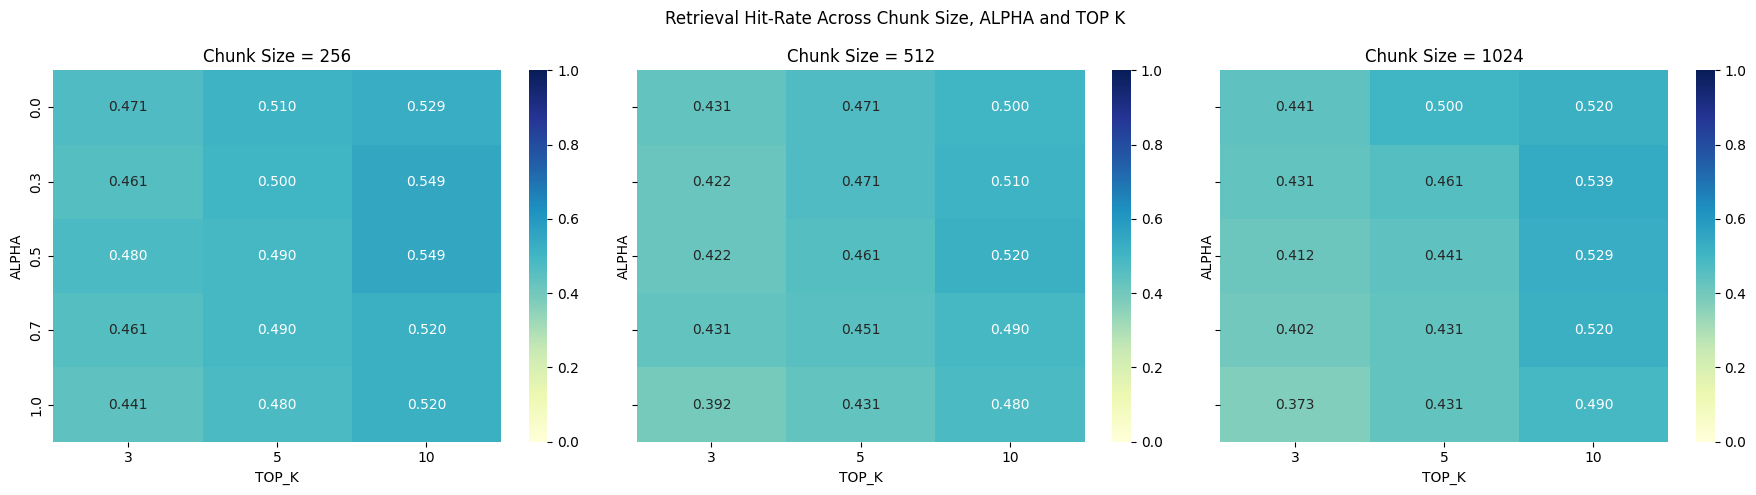

In [21]:
# Import the required packages
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size and layout
fig, axes = plt.subplots(1, len(CHUNK_SIZES), figsize = (6 * len(CHUNK_SIZES), 5), sharey = True)
if len(CHUNK_SIZES) == 1:
    axes = [axes]

# For each chunk size, plot a heat map for the retrieval hit-rate
for ax, chunk_size in zip(axes, CHUNK_SIZES):
    subset = full_sweep_df[full_sweep_df["chunk_size"] == chunk_size]
    if subset.empty:
        continue
    pivot = subset.pivot(index = "alpha", columns = "top_k", values = "hit_rate")
    sns.heatmap(pivot, annot=True, fmt = ".3f", cmap = "YlGnBu", ax = ax, vmin = 0, vmax = 1)
    ax.set_title(f"Chunk Size = {chunk_size}")
    ax.set_xlabel("TOP_K")
    ax.set_ylabel("ALPHA")

plt.suptitle("Retrieval Hit-Rate Across Chunk Size, ALPHA and TOP K")
plt.tight_layout()

# Save figure as .png
fig.savefig("retrieval_cs_a_topk_matrix.png", dpi = 400, bbox_inches = "tight")

# Show the plots
plt.show()

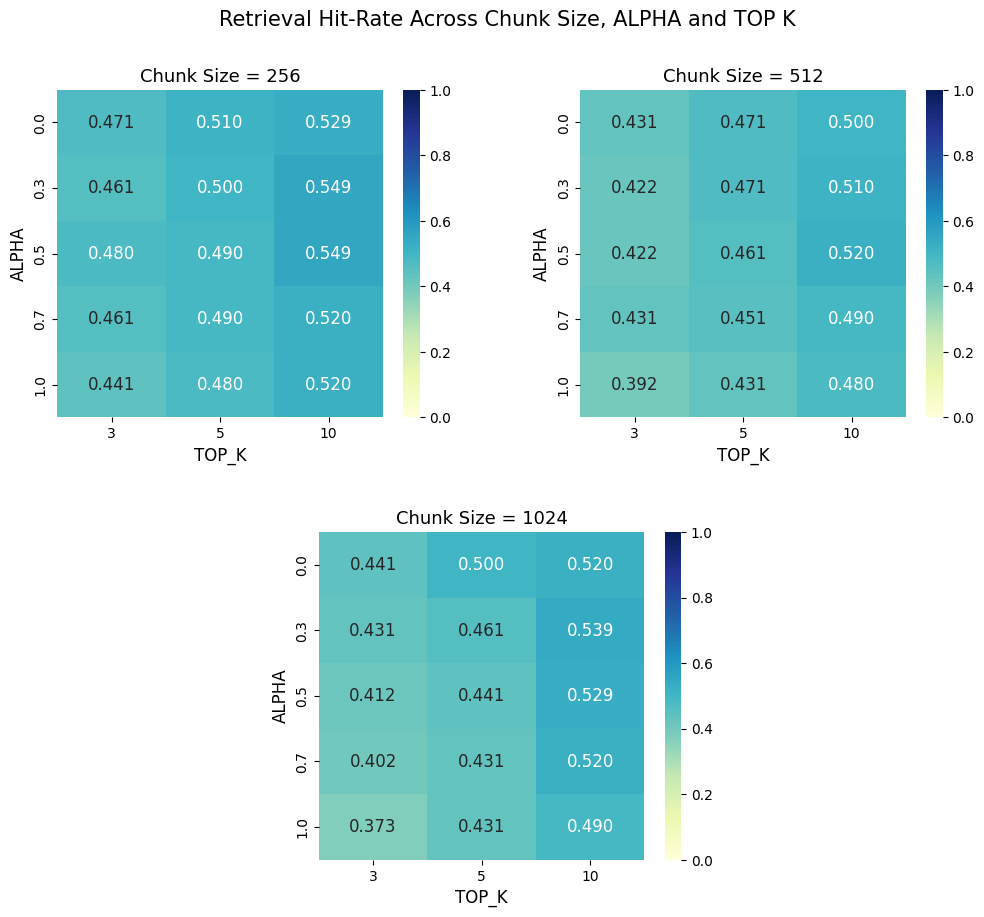

In [24]:
# Import the required packages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set the figure size
fig = plt.figure(figsize = (12, 10))

gs = gridspec.GridSpec(2, 4, figure = fig, hspace = 0.35, wspace = 0.8)

grid_positions = [gs[0, 0:2], gs[0, 2:4], gs[1, 1:3]]

# For each chunk size, plot a heat map for the retrieval hit-rate
for position, chunk_size in zip(grid_positions, CHUNK_SIZES):
    subset = full_sweep_df[full_sweep_df["chunk_size"] == chunk_size]
    if subset.empty:
        continue
    ax = fig.add_subplot(position)
    pivot = subset.pivot(index = "alpha", columns = "top_k", values = "hit_rate")
    sns.heatmap(
        pivot, annot = True, fmt = ".3f", cmap = "YlGnBu", ax = ax, vmin = 0, vmax = 1,
        annot_kws = {"size": 12},)
    ax.set_title(f"Chunk Size = {chunk_size}", fontsize = 13)
    ax.set_xlabel("TOP_K", fontsize = 12)
    ax.set_ylabel("ALPHA", fontsize = 12)

plt.suptitle("Retrieval Hit-Rate Across Chunk Size, ALPHA and TOP K", fontsize = 15, y = 0.96)

# Save figure as .png
fig.savefig("top3_retrieval_matrix.png", dpi = 400, bbox_inches = "tight")

# Show the plots
plt.show()

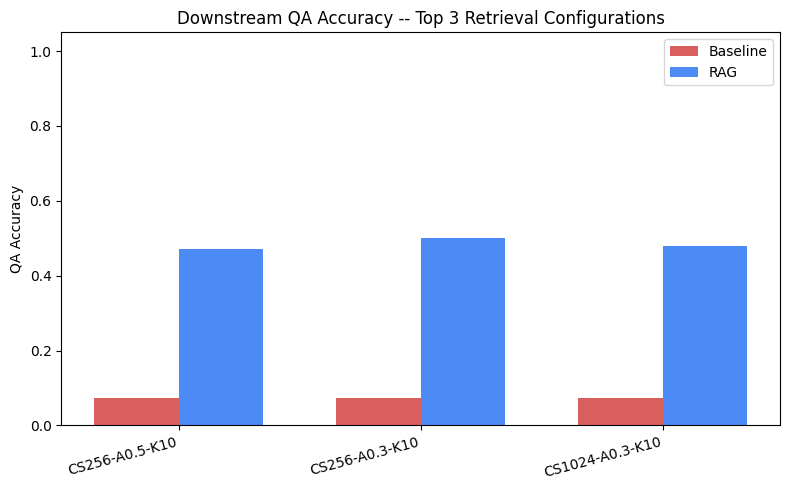

In [23]:
# Plot a bar graph of the QA accuracy for the top 3 configurations

# Set the size of the plots
fig, ax = plt.subplots(figsize = (8, 5))

# For each config, plot the baseline and RAG accuracy
x = range(len(config_summary_df))
width = 0.35

ax.bar([i - width/2 for i in x], config_summary_df["baseline_accuracy"], width, label = "Baseline", color = "#d95f5f")
ax.bar([i + width/2 for i in x], config_summary_df["rag_accuracy"], width, label = "RAG", color = "#4c8bf5")
ax.set_xticks(list(x))
ax.set_xticklabels(config_summary_df["config"], rotation = 15, ha = "right")
ax.set_ylabel("QA Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Downstream QA Accuracy -- Top 3 Retrieval Configurations")
ax.legend()

plt.tight_layout()

# Save figure as .png
fig.savefig("top3_accuracy.png", dpi = 400, bbox_inches = "tight")

# Show the plot
plt.show()